In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from bayesgpt.simulators.benchmarks import SuperDDM

In [13]:
# Initialize model
model = SuperDDM(dt=0.001, max_steps=1000)

In [14]:
# Define parameters
base_params = {
    "a": 1.0,           # Boundary separation
    "z": 0.5,           # Starting point fraction
    "tau": 0.1,         # Non-decision time
    "sigma": 1.0,       # Diffusion noise
    "angle": 0.0,       # Collapse rate
    "s_v": 0.1,         # Drift variability
    "s_z": 0.05,        # Starting point variability
    "s_tau": 0.02       # Non-decision time variability
}

In [15]:
# Context: task difficulty scales drift rates
context = np.random.uniform(0.5, 1.5, 1000)
context_modulation = lambda v, c: v * c

In [16]:
num_trials = 1000

In [17]:
# Variant 1: Single drift
params_single = base_params | {"v": 0.5}
result_single = model.simulate(
    params_single,
    num_trials,
    context,
    context_modulation
)

In [18]:
# Variant 2: Mixture drift
params_mixture = base_params | {
    "v_components": np.array([0.3, 0.7]),  # Two drift components
    "p_components": np.array([0.4, 0.6])   # Selection probabilities
}
result_mixture = model.simulate(
    params_mixture,
    num_trials,
    context,
    context_modulation
)

In [19]:
# Variant 3: Scheduled drift
params_schedule = base_params | {
    "v_schedule": np.array([[0.2, 0.6, 0.4]] * num_trials),  # Three segments
    "t_schedule": np.array([[0.2, 0.4, 0.6]] * num_trials)   # Segment durations
}
result_schedule = model.simulate(
    params_schedule,
    num_trials,
    context,
    context_modulation
)

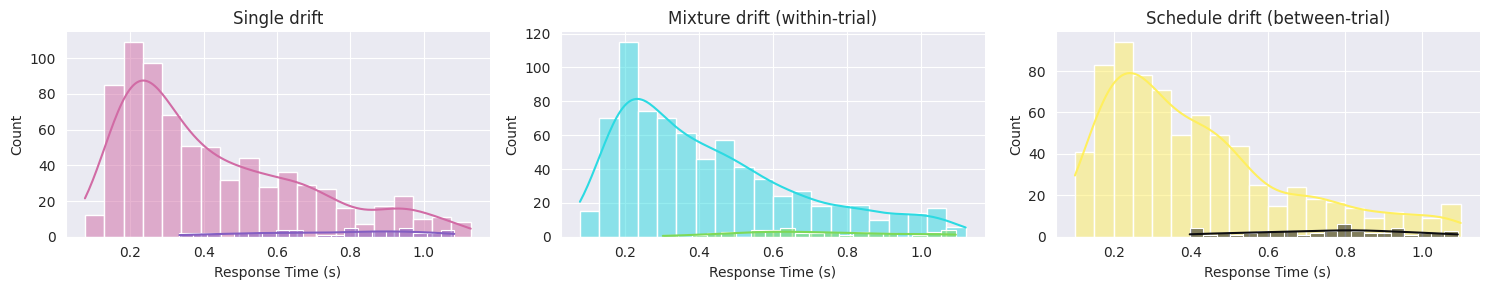

In [34]:
results = [result_single, result_mixture, result_schedule]
titles = ['Single drift', 'Mixture drift (within-trial)', 'Schedule drift (between-trial)']
colors = [
    '#D16BA5',
    '#845EC2',
    '#2CDAE2',
    '#7ED957',
    '#FFEF5E',
    '#0D0D10',
    '#FF4C5B',
    '#232946',
]

f, ax = plt.subplots(1, 3, figsize=(15, 3))

for i, (result, title) in enumerate(zip(results, titles)):
    correct = result['rts'][result["choices"] == 1]
    incorrect = result['rts'][result["choices"] == 0]

    sns.histplot(correct, kde=True, bins=20, alpha=0.5, ax=ax[i], color=colors[2*i])
    sns.histplot(incorrect, kde=True, bins=20, alpha=0.5, ax=ax[i], color=colors[2*i + 1])
    sns.despine()
    ax[i].set_title(title)
    ax[i].set_xlabel("Response Time (s)")

f.tight_layout()